In [ ]:
import matplotlib.pyplot as plt
import json
import numpy as np

datasetmap_list = {
    "Stable Code-3B":"./save/3b_stablecode_stack_v2_fim/post_eval/post_eval_fig_data.json",
    "CodeLlama-7B":"./save/7b_codellama_stack_v2_fim/post_eval/post_eval_fig_data.json",
    "CodeLlama-13B": "./save/13b_codellama_stack_v2_fim/post_eval/post_eval_fig_data.json",

    "Qwen2.5 Coder-3B":"./save/3b_qwen_stack_v2_fim/post_eval/post_eval_fig_data.json",
    "Qwen2.5 Coder-7B":"./save/7b_qwen_stack_v2_fim/post_eval/post_eval_fig_data.json",
    "Qwen2.5 Coder-14B":"./save/14b_qwen_stack_v2_fim/post_eval/post_eval_fig_data.json"
}

training_details = {
    "Stable Code-3B":"./save/3b_stablecode_stack_v2_fim/ckpts/trainer_state.json",
    "CodeLlama-7B":"./save/7b_codellama_stack_v2_fim/ckpts/trainer_state.json",
    "CodeLlama-13B":"./save/13b_codellama_stack_v2_fim/ckpts/trainer_state.json",

    "Qwen2.5 Coder-3B":"./save/3b_qwen_stack_v2_fim/ckpts/trainer_state.json",
    "Qwen2.5 Coder-7B":"./save/7b_qwen_stack_v2_fim/ckpts/trainer_state.json",
    "Qwen2.5 Coder-14B":"./save/14b_qwen_stack_v2_fim/ckpts/trainer_state.json"
}

draw_setting = {
    "password":   {"color": "#1B9E77", "shape": "o"},   
    "email":      {"color": "#D95F02", "shape": "s"},   
    "name":       {"color": "#7570B3", "shape": "d"},  
    "username":   {"color": "#E7298A", "shape": "^"},  
    "key":        {"color": "#66A61E", "shape": "x"},  
    "ip_address": {"color": "#E6AB02", "shape": ">"},   
}
import numpy as np

def downsample_grid_xy(x, y, downsample_ratio=0.1, bins=(30, 30), seed=42):
    """
    """
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    y = np.asarray(y)

    if len(x) == 0:
        return [], []

    
    xe = np.linspace(x.min(), x.max(), bins[0] + 1)
    ye = np.linspace(y.min(), y.max(), bins[1] + 1)
    xi = np.clip(np.digitize(x, xe) - 1, 0, bins[0] - 1)
    yi = np.clip(np.digitize(y, ye) - 1, 0, bins[1] - 1)

    
    buckets = {}
    for idx, (a, b) in enumerate(zip(xi, yi)):
        buckets.setdefault((a, b), []).append(idx)

    keep = []
    for idxs in buckets.values():
        m = len(idxs)
        k = max(1, int(np.floor(m * downsample_ratio)))
        if m > k:
            keep.extend(rng.choice(idxs, size=k, replace=False))
        else:
            keep.extend(idxs)

    return x[keep].tolist(), y[keep].tolist()


import json

def load_json_with_model_name(files_dict):
    data_list = []
    for model_name, file in files_dict.items():
        with open(file, 'r') as f:
            data = json.load(f)
        data_list.append((model_name, data))
    return data_list

data_list = load_json_with_model_name(datasetmap_list)

Downsampled 1200 data points to 144 data points for ip_address
Downsampled 1200 data points to 142 data points for key
Downsampled 1200 data points to 148 data points for name
Downsampled 1200 data points to 123 data points for email
Downsampled 1200 data points to 130 data points for username
Downsampled 1200 data points to 132 data points for password


/tmp/ipykernel_3856398/2625415891.py:30: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


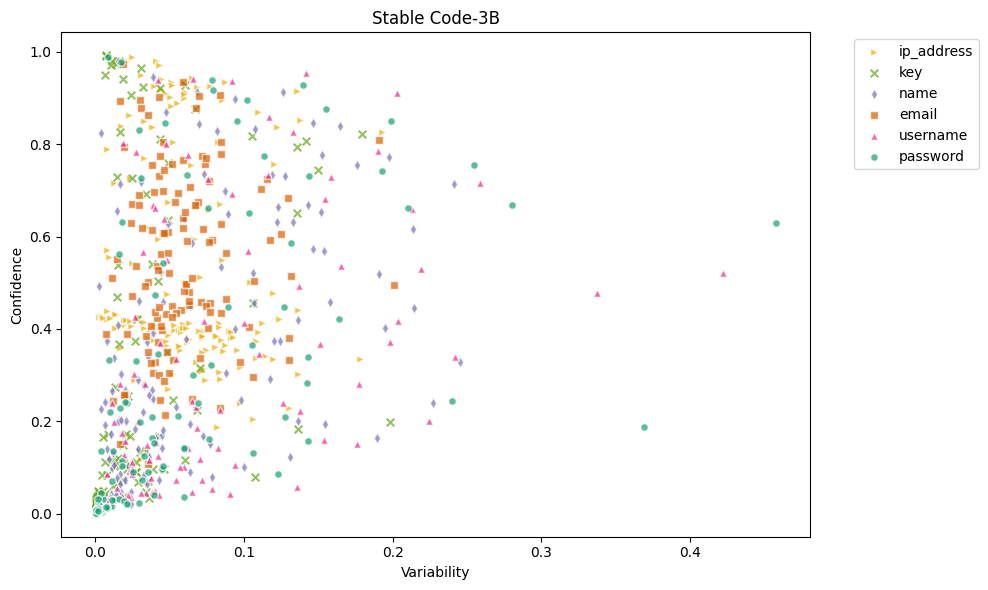

Downsampled 1200 data points to 130 data points for ip_address
Downsampled 1200 data points to 139 data points for key
Downsampled 1200 data points to 129 data points for name
Downsampled 1200 data points to 121 data points for email
Downsampled 1200 data points to 129 data points for username
Downsampled 1200 data points to 123 data points for password


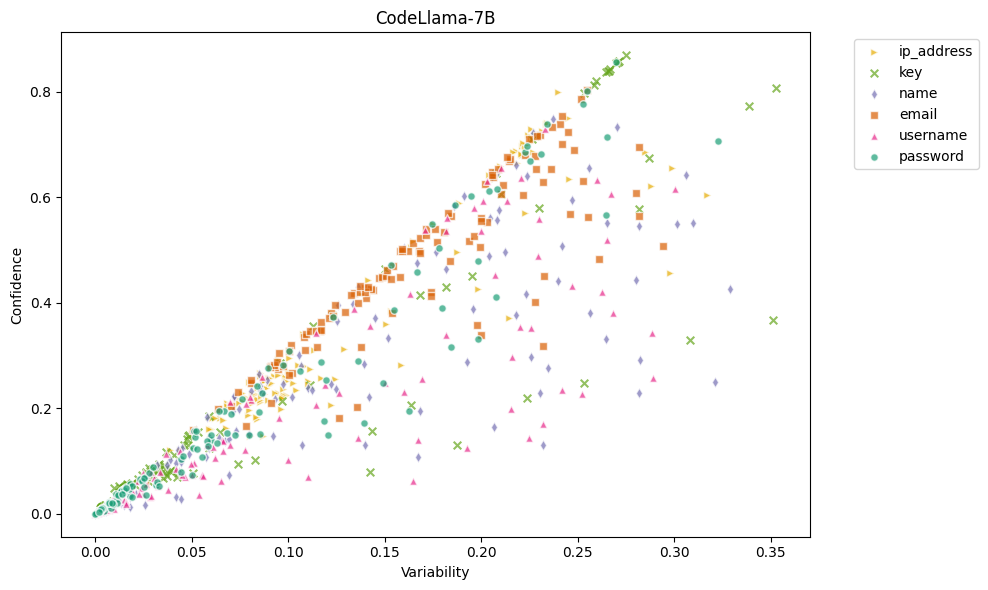

Downsampled 1200 data points to 131 data points for ip_address
Downsampled 1200 data points to 140 data points for key
Downsampled 1200 data points to 128 data points for name
Downsampled 1200 data points to 127 data points for email
Downsampled 1200 data points to 131 data points for username
Downsampled 1200 data points to 130 data points for password


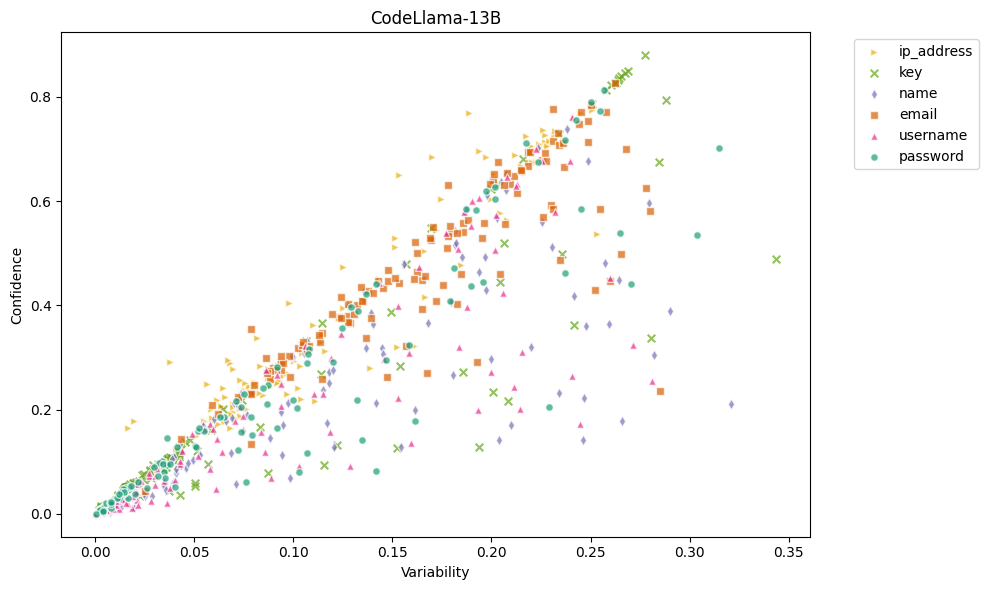

Downsampled 1200 data points to 143 data points for ip_address
Downsampled 1200 data points to 139 data points for key
Downsampled 1200 data points to 136 data points for name
Downsampled 1200 data points to 123 data points for email
Downsampled 1200 data points to 146 data points for username
Downsampled 1200 data points to 139 data points for password


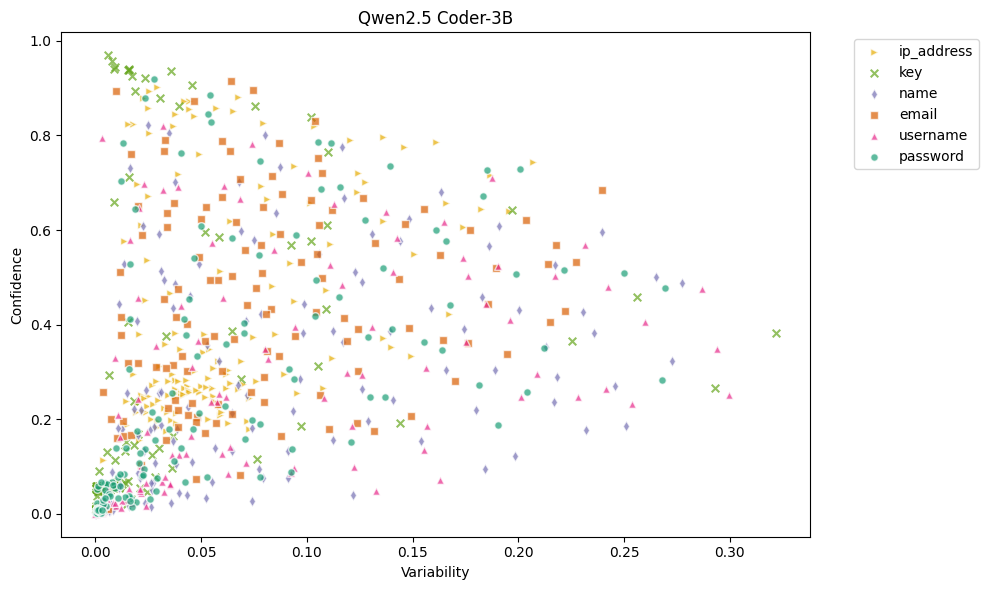

Downsampled 1200 data points to 136 data points for ip_address
Downsampled 1200 data points to 149 data points for key
Downsampled 1200 data points to 132 data points for name
Downsampled 1200 data points to 124 data points for email
Downsampled 1200 data points to 140 data points for username
Downsampled 1200 data points to 143 data points for password


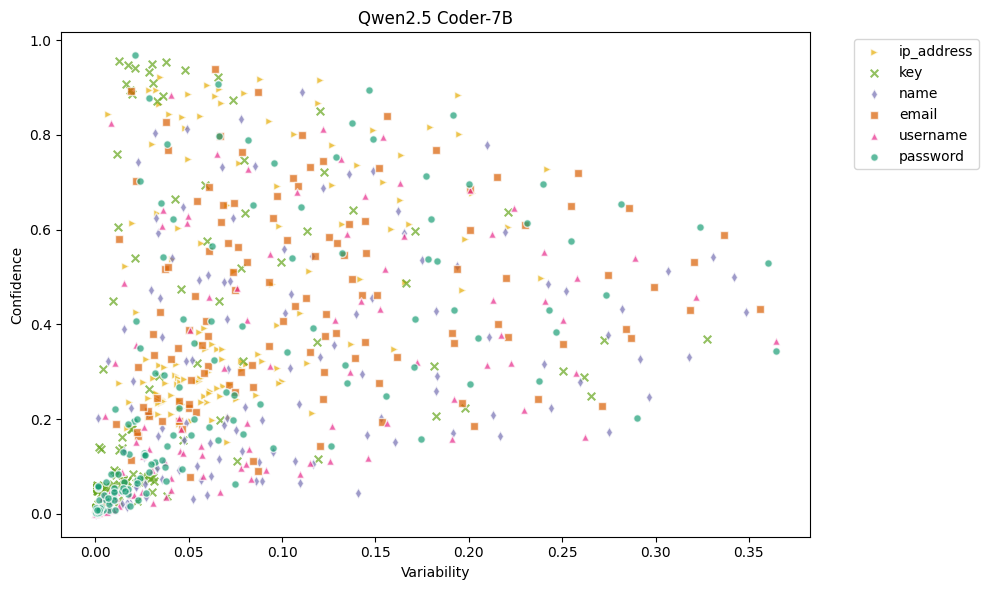

Downsampled 1200 data points to 136 data points for ip_address
Downsampled 1200 data points to 149 data points for key
Downsampled 1200 data points to 128 data points for name
Downsampled 1200 data points to 123 data points for email
Downsampled 1200 data points to 143 data points for username
Downsampled 1200 data points to 136 data points for password


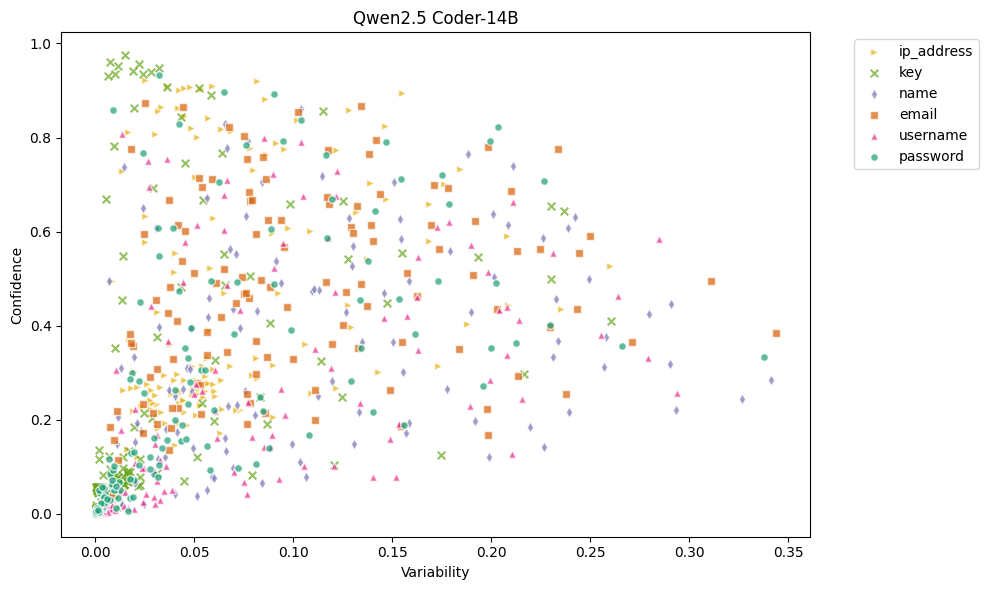

In [96]:

node_size = 30
alpha_value = 0.7
def sub_plot_dataset_map(draw_setting, dataset, model_name, ds_frac=0.1, ax_sub=None, legend=True):
    if ax_sub is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax_sub.get_figure()
        ax = ax_sub

    confidences_by_type = dataset.get("confidences_by_type", {})
    variabilities_by_type = dataset.get("variabilities_by_type", {})
    
    pii_types = list(confidences_by_type.keys())
    n_types = len(pii_types)

    for pii_type in pii_types:
        confidences = confidences_by_type[pii_type]
        variabilities = variabilities_by_type[pii_type]
        n = len(variabilities)

        # Downsample the data size by ds_frac for each pii_type within
        x = variabilities
        y = confidences
        if ds_frac < 1.0:
            x, y = downsample_grid_xy(x, y, downsample_ratio=ds_frac, bins=(10, 10))
            print(f"Downsampled {n} data points to {len(x)} data points for {pii_type}")

        # To distinguish datasets, use alpha and label
        label = pii_type
        ax.scatter(
            x, y,
            label=label,
            c=draw_setting[pii_type]["color"],
            marker=draw_setting[pii_type]["shape"],
            edgecolors='white',
            alpha=alpha_value,
            s=node_size
        )
    ax.set_xlabel("Variability")
    ax.set_ylabel("Confidence")
    ax.set_title(f"{model_name}")
    if legend:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    #ax.grid(True)
    if ax_sub is None:
        plt.tight_layout()
        plt.show()
    

for model_name, dataset in data_list:
    sub_plot_dataset_map(draw_setting, dataset, model_name)
    
    
    
    
    

Downsampled 1200 data points to 144 data points for ip_address
Downsampled 1200 data points to 142 data points for key
Downsampled 1200 data points to 148 data points for name
Downsampled 1200 data points to 123 data points for email
Downsampled 1200 data points to 130 data points for username
Downsampled 1200 data points to 132 data points for password
Downsampled 1200 data points to 130 data points for ip_address
Downsampled 1200 data points to 139 data points for key
Downsampled 1200 data points to 129 data points for name
Downsampled 1200 data points to 121 data points for email
Downsampled 1200 data points to 129 data points for username
Downsampled 1200 data points to 123 data points for password
Downsampled 1200 data points to 131 data points for ip_address
Downsampled 1200 data points to 140 data points for key
Downsampled 1200 data points to 128 data points for name
Downsampled 1200 data points to 127 data points for email
Downsampled 1200 data points to 131 data points for us

/tmp/ipykernel_3856398/650180832.py:28: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


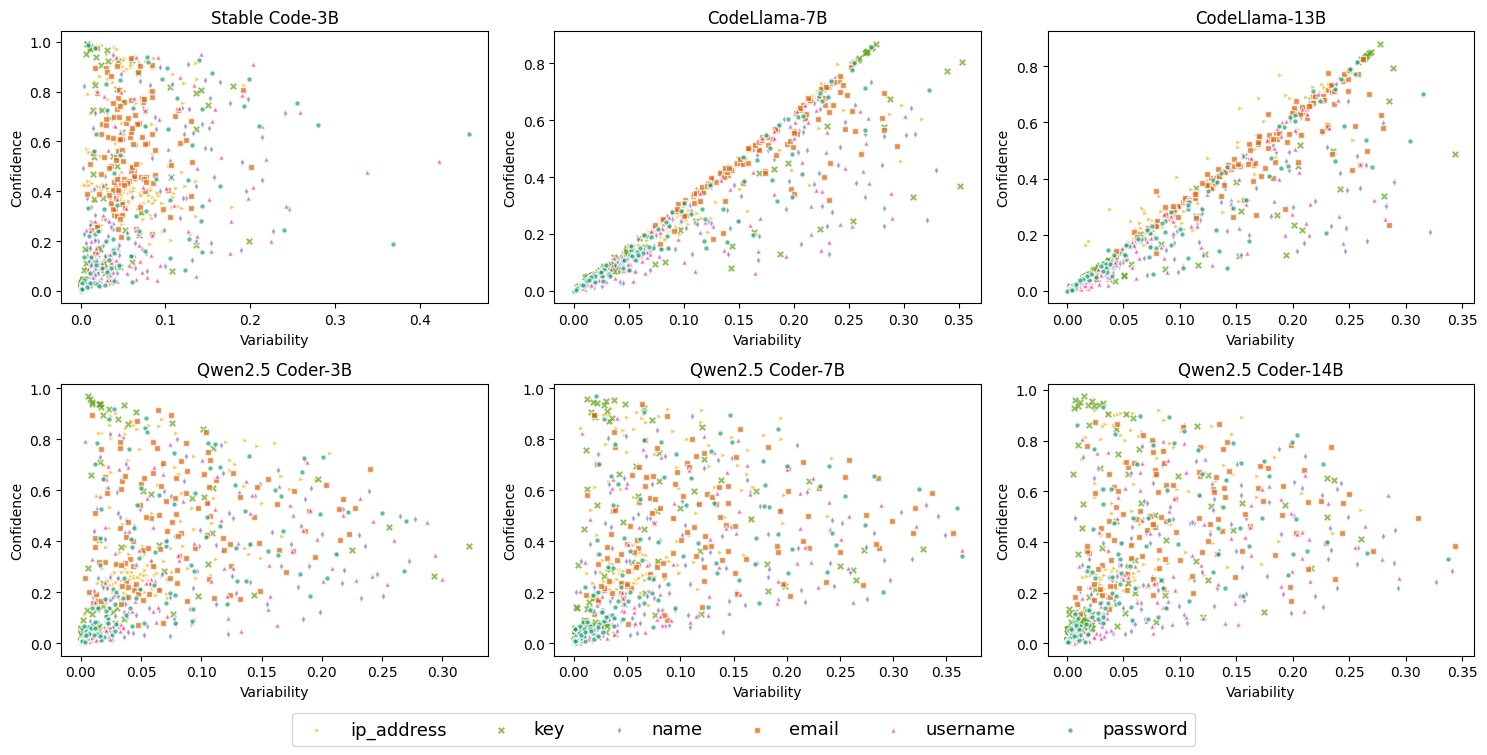

In [ ]:
node_size = 30
alpha_value = 0.7

def sub_plot_dataset_map(draw_setting, dataset, model_name, ds_frac=0.1, ax_sub=None, legend=False):
    if ax_sub is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax_sub.get_figure()
        ax = ax_sub

    confidences_by_type = dataset.get("confidences_by_type", {})
    variabilities_by_type = dataset.get("variabilities_by_type", {})
    
    pii_types = list(confidences_by_type.keys())

    for pii_type in pii_types:
        confidences = confidences_by_type[pii_type]
        variabilities = variabilities_by_type[pii_type]
        n = len(variabilities)

        # Downsample
        x = variabilities
        y = confidences
        if ds_frac < 1.0:
            x, y = downsample_grid_xy(x, y, downsample_ratio=ds_frac, bins=(10, 10))
            print(f"Downsampled {n} data points to {len(x)} data points for {pii_type}")

        ax.scatter(
            x, y,
            label=pii_type,
            c=draw_setting[pii_type]["color"],
            marker=draw_setting[pii_type]["shape"],
            edgecolors='white',
            alpha=alpha_value,
            s=node_size
        )
    ax.set_xlabel("Variability")
    ax.set_ylabel("Confidence")
    ax.set_title(f"{model_name}")
    

    if ax_sub is None:
        plt.tight_layout()
        plt.show()



node_size = node_size // 2
n_datasets = len(data_list)

cols = min(3, n_datasets)
rows = (n_datasets + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
if rows == 1 and cols == 1:
    axes = [[axes]]
elif rows == 1:
    axes = [axes]
elif cols == 1:
    axes = [[ax] for ax in axes]

for i, (model_name, dataset) in enumerate(data_list):
    row_idx = i // cols
    col_idx = i % cols
    sub_plot_dataset_map(draw_setting, dataset, model_name, ax_sub=axes[row_idx][col_idx], legend=False)


handles, labels = axes[0][0].get_legend_handles_labels()
plt.subplots_adjust(bottom=0.20)  
fig.legend(handles, labels, loc='lower center', ncol=len(labels), fontsize=13)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])  
plt.savefig("pdf/dataset_map.pdf")
plt.show()



=== ip_address (confidence) ===
Bin 0.1~0.2: 0.0
Bin 0.2~0.3: 0.02
Bin 0.3~0.4: 0.38
Bin 0.4~0.5: 0.28
Bin 0.5~0.6: 0.01
Bin 0.6~0.7: 0.01
Bin 0.7~0.8: 0.02
Bin 0.8~0.9: 0.09
Bin 0.9~1.0: 0.17
Sum of bins >= 0.5: 374 (0.31)

=== key (confidence) ===
Bin 0.0~0.1: 0.66
Bin 0.1~0.2: 0.17
Bin 0.2~0.3: 0.02
Bin 0.3~0.4: 0.01
Bin 0.4~0.5: 0.01
Bin 0.5~0.6: 0.0
Bin 0.6~0.7: 0.0
Bin 0.7~0.8: 0.01
Bin 0.8~0.9: 0.01
Bin 0.9~1.0: 0.11
Sum of bins >= 0.5: 160 (0.13)

=== name (confidence) ===
Bin 0.0~0.1: 0.37
Bin 0.1~0.2: 0.17
Bin 0.2~0.3: 0.14
Bin 0.3~0.4: 0.08
Bin 0.4~0.5: 0.04
Bin 0.5~0.6: 0.03
Bin 0.6~0.7: 0.08
Bin 0.7~0.8: 0.04
Bin 0.8~0.9: 0.03
Bin 0.9~1.0: 0.01
Sum of bins >= 0.5: 222 (0.18)

=== email (confidence) ===
Bin 0.0~0.1: 0.0
Bin 0.1~0.2: 0.01
Bin 0.2~0.3: 0.06
Bin 0.3~0.4: 0.15
Bin 0.4~0.5: 0.21
Bin 0.5~0.6: 0.18
Bin 0.6~0.7: 0.17
Bin 0.7~0.8: 0.13
Bin 0.8~0.9: 0.05
Bin 0.9~1.0: 0.04
Sum of bins >= 0.5: 688 (0.57)

=== username (confidence) ===
Bin 0.0~0.1: 0.49
Bin 0.1~0.2: 0.

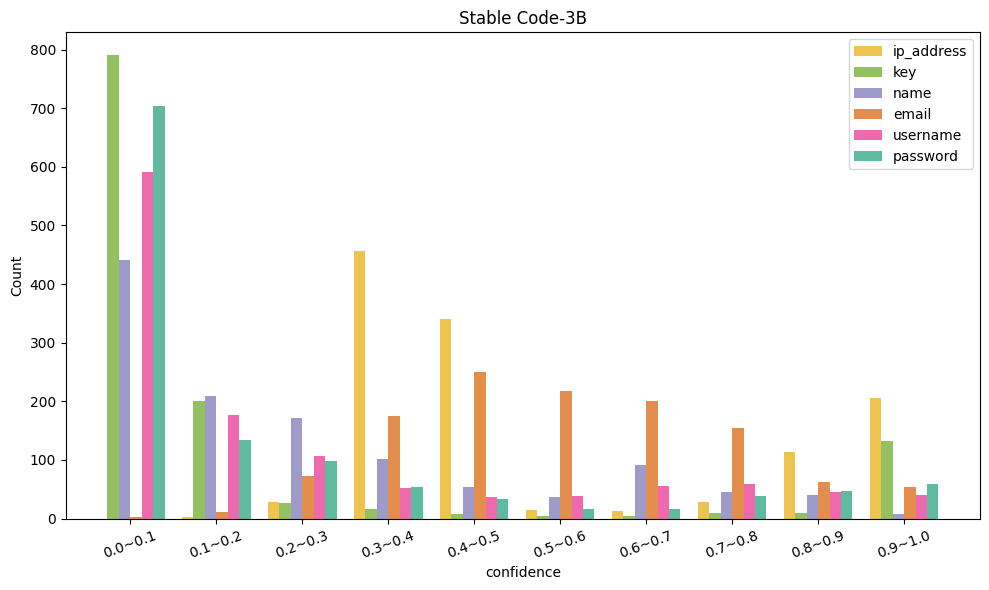


=== ip_address (variability) ===
Bin 0.0~0.1: 0.95
Bin 0.1~0.2: 0.05
Sum of bins >= 0.5: 0 (0.0)

=== key (variability) ===
Bin 0.0~0.1: 0.99
Bin 0.1~0.2: 0.01
Sum of bins >= 0.5: 0 (0.0)

=== name (variability) ===
Bin 0.0~0.1: 0.89
Bin 0.1~0.2: 0.1
Bin 0.2~0.3: 0.0
Sum of bins >= 0.5: 0 (0.0)

=== email (variability) ===
Bin 0.0~0.1: 0.97
Bin 0.1~0.2: 0.02
Bin 0.2~0.3: 0.0
Sum of bins >= 0.5: 0 (0.0)

=== username (variability) ===
Bin 0.0~0.1: 0.91
Bin 0.1~0.2: 0.08
Bin 0.2~0.3: 0.01
Bin 0.3~0.4: 0.0
Bin 0.4~0.5: 0.0
Sum of bins >= 0.5: 0 (0.0)

=== password (variability) ===
Bin 0.0~0.1: 0.94
Bin 0.1~0.2: 0.05
Bin 0.2~0.3: 0.01
Bin 0.3~0.4: 0.0
Bin 0.4~0.5: 0.0
Sum of bins >= 0.5: 0 (0.0)


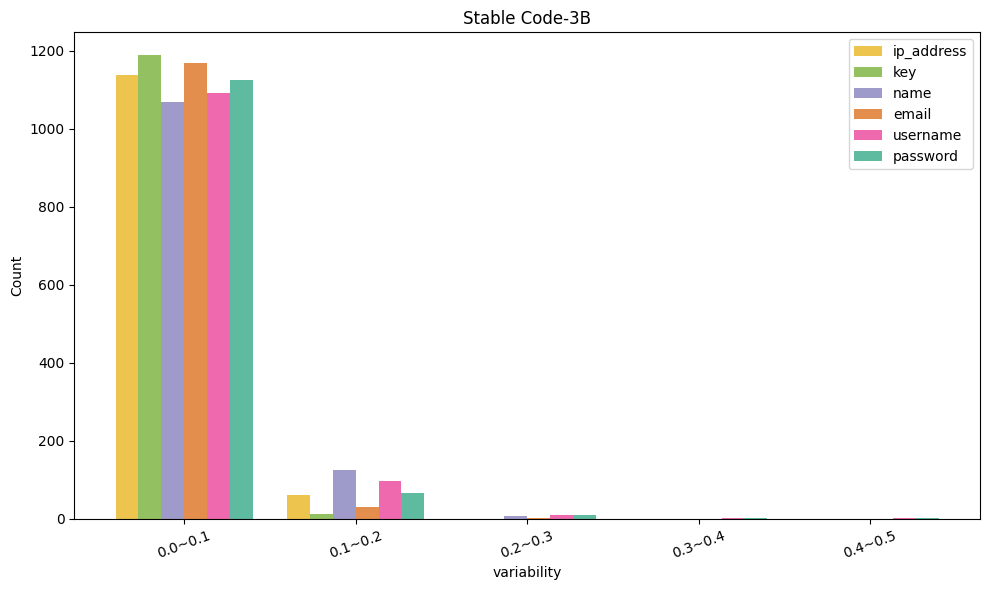


=== ip_address (confidence) ===
Bin 0.0~0.1: 0.0
Bin 0.1~0.2: 0.16
Bin 0.2~0.3: 0.5
Bin 0.3~0.4: 0.04
Bin 0.4~0.5: 0.02
Bin 0.5~0.6: 0.02
Bin 0.6~0.7: 0.12
Bin 0.7~0.8: 0.14
Sum of bins >= 0.5: 327 (0.27)

=== key (confidence) ===
Bin 0.0~0.1: 0.76
Bin 0.1~0.2: 0.09
Bin 0.2~0.3: 0.02
Bin 0.3~0.4: 0.01
Bin 0.4~0.5: 0.01
Bin 0.5~0.6: 0.01
Bin 0.6~0.7: 0.01
Bin 0.7~0.8: 0.02
Bin 0.8~0.9: 0.09
Sum of bins >= 0.5: 146 (0.12)

=== name (confidence) ===
Bin 0.0~0.1: 0.33
Bin 0.1~0.2: 0.18
Bin 0.2~0.3: 0.16
Bin 0.3~0.4: 0.09
Bin 0.4~0.5: 0.08
Bin 0.5~0.6: 0.09
Bin 0.6~0.7: 0.05
Bin 0.7~0.8: 0.02
Sum of bins >= 0.5: 189 (0.16)

=== email (confidence) ===
Bin 0.0~0.1: 0.0
Bin 0.1~0.2: 0.02
Bin 0.2~0.3: 0.14
Bin 0.3~0.4: 0.2
Bin 0.4~0.5: 0.21
Bin 0.5~0.6: 0.18
Bin 0.6~0.7: 0.16
Bin 0.7~0.8: 0.08
Bin 0.8~0.9: 0.01
Sum of bins >= 0.5: 518 (0.43)

=== username (confidence) ===
Bin 0.0~0.1: 0.55
Bin 0.1~0.2: 0.16
Bin 0.2~0.3: 0.08
Bin 0.3~0.4: 0.05
Bin 0.4~0.5: 0.04
Bin 0.5~0.6: 0.06
Bin 0.6~0.7: 0.

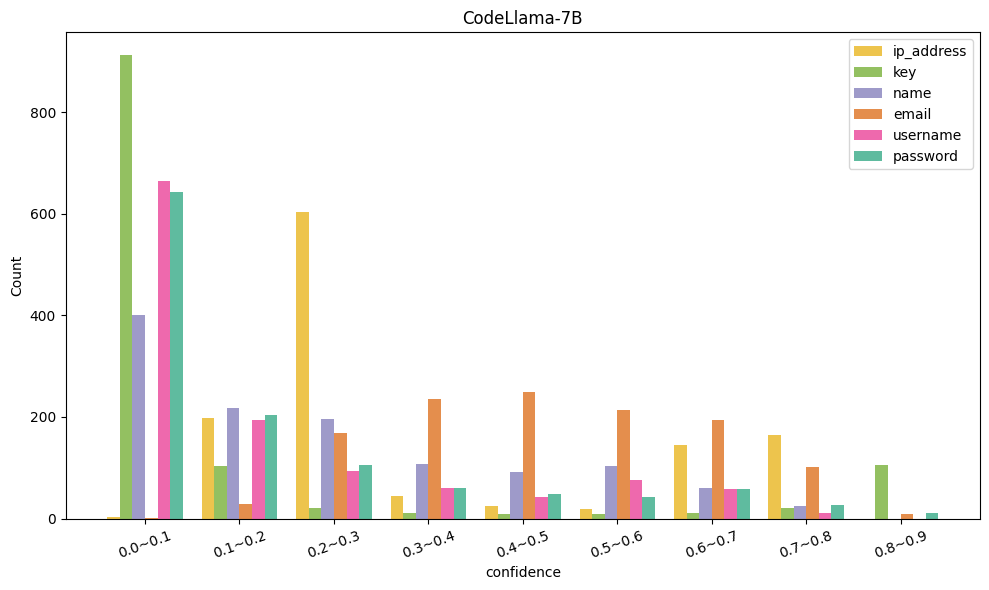


=== ip_address (variability) ===
Bin 0.0~0.1: 0.55
Bin 0.1~0.2: 0.19
Bin 0.2~0.3: 0.26
Bin 0.3~0.4: 0.0
Sum of bins >= 0.5: 0 (0.0)

=== key (variability) ===
Bin 0.0~0.1: 0.85
Bin 0.1~0.2: 0.03
Bin 0.2~0.3: 0.12
Bin 0.3~0.4: 0.0
Sum of bins >= 0.5: 0 (0.0)

=== name (variability) ===
Bin 0.0~0.1: 0.58
Bin 0.1~0.2: 0.23
Bin 0.2~0.3: 0.19
Bin 0.3~0.4: 0.0
Sum of bins >= 0.5: 0 (0.0)

=== email (variability) ===
Bin 0.0~0.1: 0.16
Bin 0.1~0.2: 0.53
Bin 0.2~0.3: 0.31
Bin 0.3~0.4: 0.0
Sum of bins >= 0.5: 0 (0.0)

=== username (variability) ===
Bin 0.0~0.1: 0.69
Bin 0.1~0.2: 0.19
Bin 0.2~0.3: 0.12
Bin 0.3~0.4: 0.0
Sum of bins >= 0.5: 0 (0.0)

=== password (variability) ===
Bin 0.0~0.1: 0.74
Bin 0.1~0.2: 0.17
Bin 0.2~0.3: 0.08
Bin 0.3~0.4: 0.0
Sum of bins >= 0.5: 0 (0.0)


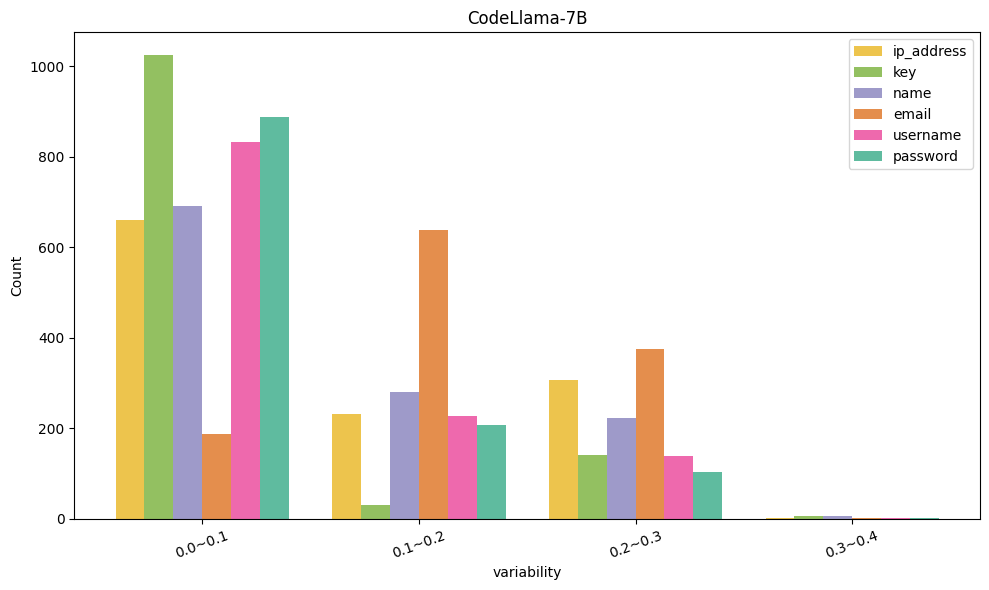


=== ip_address (confidence) ===
Bin 0.1~0.2: 0.13
Bin 0.2~0.3: 0.48
Bin 0.3~0.4: 0.09
Bin 0.4~0.5: 0.02
Bin 0.5~0.6: 0.02
Bin 0.6~0.7: 0.13
Bin 0.7~0.8: 0.13
Bin 0.8~0.9: 0.0
Sum of bins >= 0.5: 333 (0.28)

=== key (confidence) ===
Bin 0.0~0.1: 0.7
Bin 0.1~0.2: 0.14
Bin 0.2~0.3: 0.02
Bin 0.3~0.4: 0.01
Bin 0.4~0.5: 0.01
Bin 0.5~0.6: 0.01
Bin 0.6~0.7: 0.01
Bin 0.7~0.8: 0.02
Bin 0.8~0.9: 0.09
Sum of bins >= 0.5: 146 (0.12)

=== name (confidence) ===
Bin 0.0~0.1: 0.34
Bin 0.1~0.2: 0.19
Bin 0.2~0.3: 0.15
Bin 0.3~0.4: 0.09
Bin 0.4~0.5: 0.08
Bin 0.5~0.6: 0.08
Bin 0.6~0.7: 0.04
Bin 0.7~0.8: 0.02
Sum of bins >= 0.5: 174 (0.14)

=== email (confidence) ===
Bin 0.0~0.1: 0.0
Bin 0.1~0.2: 0.02
Bin 0.2~0.3: 0.15
Bin 0.3~0.4: 0.19
Bin 0.4~0.5: 0.2
Bin 0.5~0.6: 0.18
Bin 0.6~0.7: 0.15
Bin 0.7~0.8: 0.09
Bin 0.8~0.9: 0.01
Sum of bins >= 0.5: 512 (0.43)

=== username (confidence) ===
Bin 0.0~0.1: 0.57
Bin 0.1~0.2: 0.16
Bin 0.2~0.3: 0.07
Bin 0.3~0.4: 0.04
Bin 0.4~0.5: 0.04
Bin 0.5~0.6: 0.06
Bin 0.6~0.7: 0.

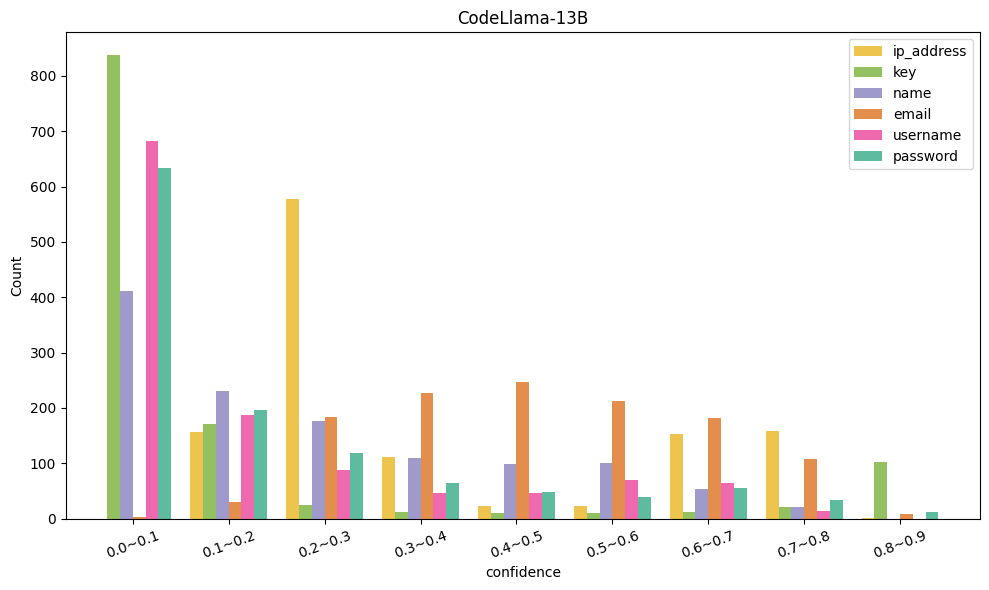


=== ip_address (variability) ===
Bin 0.0~0.1: 0.6
Bin 0.1~0.2: 0.17
Bin 0.2~0.3: 0.23
Sum of bins >= 0.5: 0 (0.0)

=== key (variability) ===
Bin 0.0~0.1: 0.85
Bin 0.1~0.2: 0.03
Bin 0.2~0.3: 0.12
Bin 0.3~0.4: 0.0
Sum of bins >= 0.5: 0 (0.0)

=== name (variability) ===
Bin 0.0~0.1: 0.58
Bin 0.1~0.2: 0.27
Bin 0.2~0.3: 0.14
Bin 0.3~0.4: 0.0
Sum of bins >= 0.5: 0 (0.0)

=== email (variability) ===
Bin 0.0~0.1: 0.18
Bin 0.1~0.2: 0.54
Bin 0.2~0.3: 0.28
Sum of bins >= 0.5: 0 (0.0)

=== username (variability) ===
Bin 0.0~0.1: 0.74
Bin 0.1~0.2: 0.18
Bin 0.2~0.3: 0.09
Sum of bins >= 0.5: 0 (0.0)

=== password (variability) ===
Bin 0.0~0.1: 0.75
Bin 0.1~0.2: 0.16
Bin 0.2~0.3: 0.09
Bin 0.3~0.4: 0.0
Sum of bins >= 0.5: 0 (0.0)


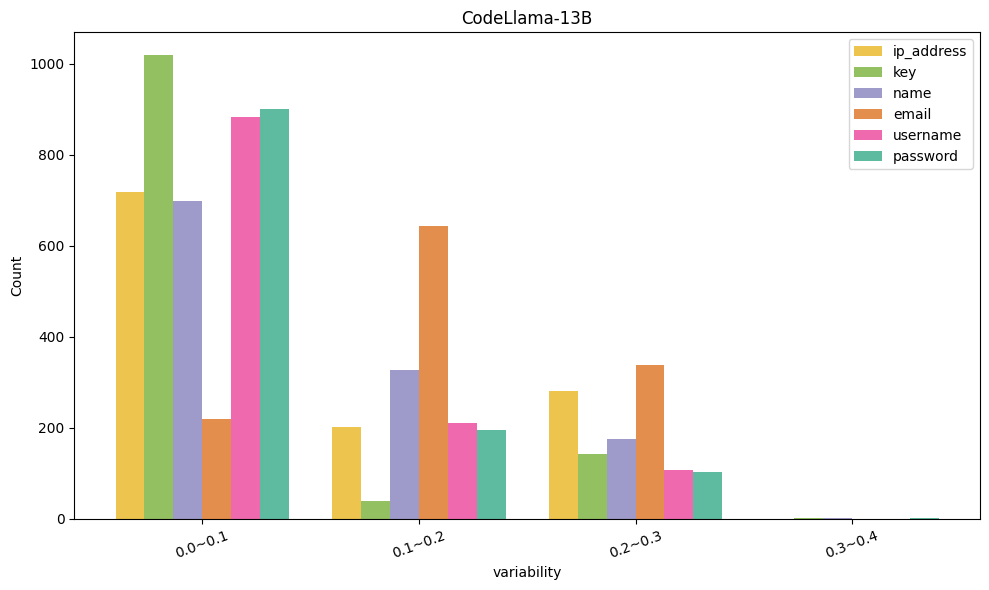


=== ip_address (confidence) ===
Bin 0.1~0.2: 0.07
Bin 0.2~0.3: 0.48
Bin 0.3~0.4: 0.12
Bin 0.4~0.5: 0.01
Bin 0.5~0.6: 0.02
Bin 0.6~0.7: 0.04
Bin 0.7~0.8: 0.1
Bin 0.8~0.9: 0.15
Bin 0.9~1.0: 0.01
Sum of bins >= 0.5: 380 (0.32)

=== key (confidence) ===
Bin 0.0~0.1: 0.76
Bin 0.1~0.2: 0.07
Bin 0.2~0.3: 0.01
Bin 0.3~0.4: 0.01
Bin 0.4~0.5: 0.0
Bin 0.5~0.6: 0.01
Bin 0.6~0.7: 0.01
Bin 0.7~0.8: 0.0
Bin 0.8~0.9: 0.02
Bin 0.9~1.0: 0.1
Sum of bins >= 0.5: 167 (0.14)

=== name (confidence) ===
Bin 0.0~0.1: 0.34
Bin 0.1~0.2: 0.16
Bin 0.2~0.3: 0.15
Bin 0.3~0.4: 0.1
Bin 0.4~0.5: 0.11
Bin 0.5~0.6: 0.08
Bin 0.6~0.7: 0.04
Bin 0.7~0.8: 0.02
Bin 0.8~0.9: 0.01
Sum of bins >= 0.5: 167 (0.14)

=== email (confidence) ===
Bin 0.0~0.1: 0.01
Bin 0.1~0.2: 0.09
Bin 0.2~0.3: 0.16
Bin 0.3~0.4: 0.16
Bin 0.4~0.5: 0.18
Bin 0.5~0.6: 0.14
Bin 0.6~0.7: 0.13
Bin 0.7~0.8: 0.09
Bin 0.8~0.9: 0.02
Bin 0.9~1.0: 0.0
Sum of bins >= 0.5: 463 (0.39)

=== username (confidence) ===
Bin 0.0~0.1: 0.61
Bin 0.1~0.2: 0.12
Bin 0.2~0.3: 0.08

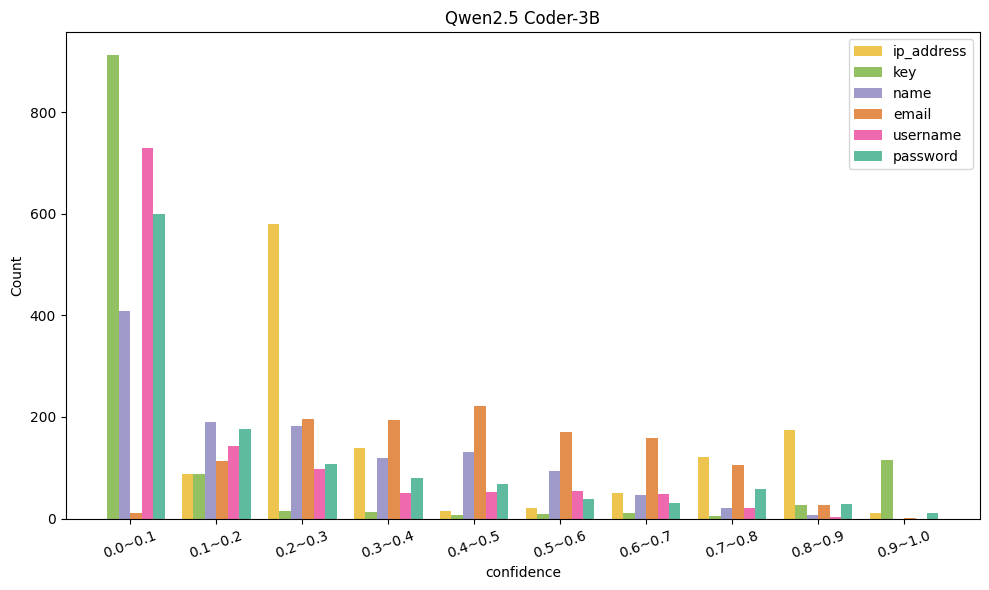


=== ip_address (variability) ===
Bin 0.0~0.1: 0.92
Bin 0.1~0.2: 0.08
Bin 0.2~0.3: 0.0
Sum of bins >= 0.5: 0 (0.0)

=== key (variability) ===
Bin 0.0~0.1: 0.98
Bin 0.1~0.2: 0.01
Bin 0.2~0.3: 0.0
Bin 0.3~0.4: 0.0
Sum of bins >= 0.5: 0 (0.0)

=== name (variability) ===
Bin 0.0~0.1: 0.81
Bin 0.1~0.2: 0.17
Bin 0.2~0.3: 0.02
Sum of bins >= 0.5: 0 (0.0)

=== email (variability) ===
Bin 0.0~0.1: 0.77
Bin 0.1~0.2: 0.22
Bin 0.2~0.3: 0.01
Sum of bins >= 0.5: 0 (0.0)

=== username (variability) ===
Bin 0.0~0.1: 0.88
Bin 0.1~0.2: 0.11
Bin 0.2~0.3: 0.02
Sum of bins >= 0.5: 0 (0.0)

=== password (variability) ===
Bin 0.0~0.1: 0.89
Bin 0.1~0.2: 0.1
Bin 0.2~0.3: 0.01
Sum of bins >= 0.5: 0 (0.0)


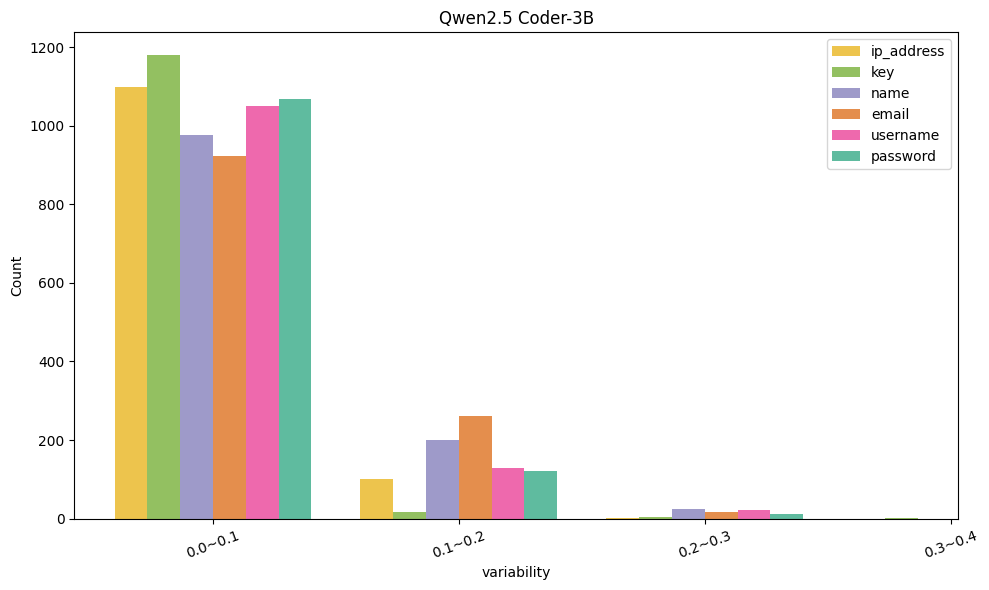


=== ip_address (confidence) ===
Bin 0.1~0.2: 0.06
Bin 0.2~0.3: 0.46
Bin 0.3~0.4: 0.15
Bin 0.4~0.5: 0.02
Bin 0.5~0.6: 0.01
Bin 0.6~0.7: 0.03
Bin 0.7~0.8: 0.07
Bin 0.8~0.9: 0.16
Bin 0.9~1.0: 0.04
Sum of bins >= 0.5: 376 (0.31)

=== key (confidence) ===
Bin 0.0~0.1: 0.74
Bin 0.1~0.2: 0.08
Bin 0.2~0.3: 0.02
Bin 0.3~0.4: 0.01
Bin 0.4~0.5: 0.01
Bin 0.5~0.6: 0.01
Bin 0.6~0.7: 0.01
Bin 0.7~0.8: 0.0
Bin 0.8~0.9: 0.02
Bin 0.9~1.0: 0.1
Sum of bins >= 0.5: 169 (0.14)

=== name (confidence) ===
Bin 0.0~0.1: 0.32
Bin 0.1~0.2: 0.18
Bin 0.2~0.3: 0.14
Bin 0.3~0.4: 0.11
Bin 0.4~0.5: 0.12
Bin 0.5~0.6: 0.07
Bin 0.6~0.7: 0.04
Bin 0.7~0.8: 0.02
Bin 0.8~0.9: 0.01
Sum of bins >= 0.5: 156 (0.13)

=== email (confidence) ===
Bin 0.0~0.1: 0.01
Bin 0.1~0.2: 0.09
Bin 0.2~0.3: 0.17
Bin 0.3~0.4: 0.18
Bin 0.4~0.5: 0.16
Bin 0.5~0.6: 0.15
Bin 0.6~0.7: 0.12
Bin 0.7~0.8: 0.08
Bin 0.8~0.9: 0.03
Bin 0.9~1.0: 0.0
Sum of bins >= 0.5: 467 (0.39)

=== username (confidence) ===
Bin 0.0~0.1: 0.59
Bin 0.1~0.2: 0.13
Bin 0.2~0.3: 0

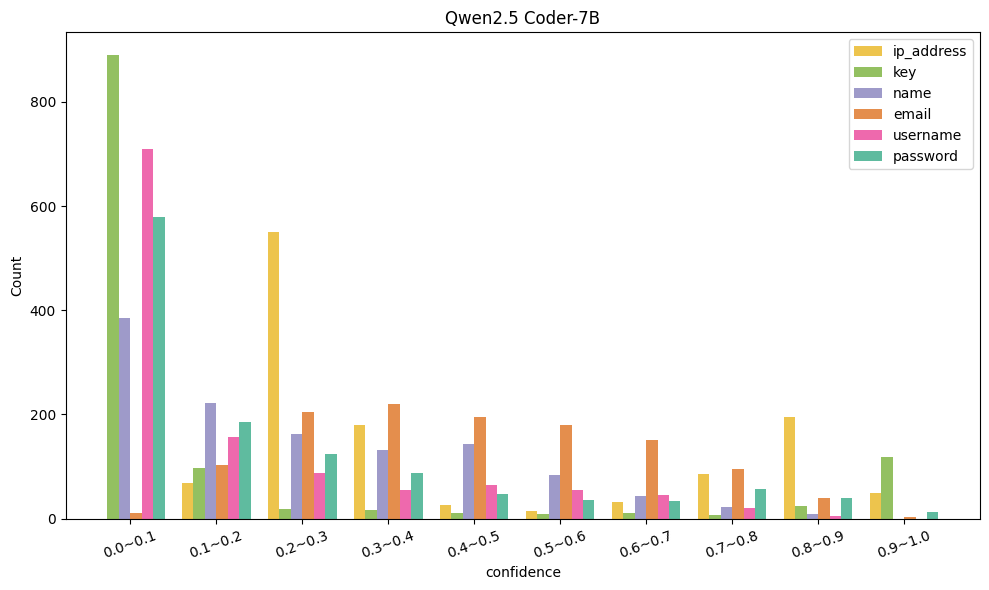


=== ip_address (variability) ===
Bin 0.0~0.1: 0.87
Bin 0.1~0.2: 0.12
Bin 0.2~0.3: 0.01
Sum of bins >= 0.5: 0 (0.0)

=== key (variability) ===
Bin 0.0~0.1: 0.98
Bin 0.1~0.2: 0.01
Bin 0.2~0.3: 0.0
Bin 0.3~0.4: 0.0
Sum of bins >= 0.5: 0 (0.0)

=== name (variability) ===
Bin 0.0~0.1: 0.7
Bin 0.1~0.2: 0.23
Bin 0.2~0.3: 0.07
Bin 0.3~0.4: 0.01
Sum of bins >= 0.5: 0 (0.0)

=== email (variability) ===
Bin 0.0~0.1: 0.6
Bin 0.1~0.2: 0.32
Bin 0.2~0.3: 0.08
Bin 0.3~0.4: 0.0
Sum of bins >= 0.5: 0 (0.0)

=== username (variability) ===
Bin 0.0~0.1: 0.81
Bin 0.1~0.2: 0.15
Bin 0.2~0.3: 0.04
Bin 0.3~0.4: 0.0
Sum of bins >= 0.5: 0 (0.0)

=== password (variability) ===
Bin 0.0~0.1: 0.89
Bin 0.1~0.2: 0.1
Bin 0.2~0.3: 0.01
Bin 0.3~0.4: 0.0
Sum of bins >= 0.5: 0 (0.0)


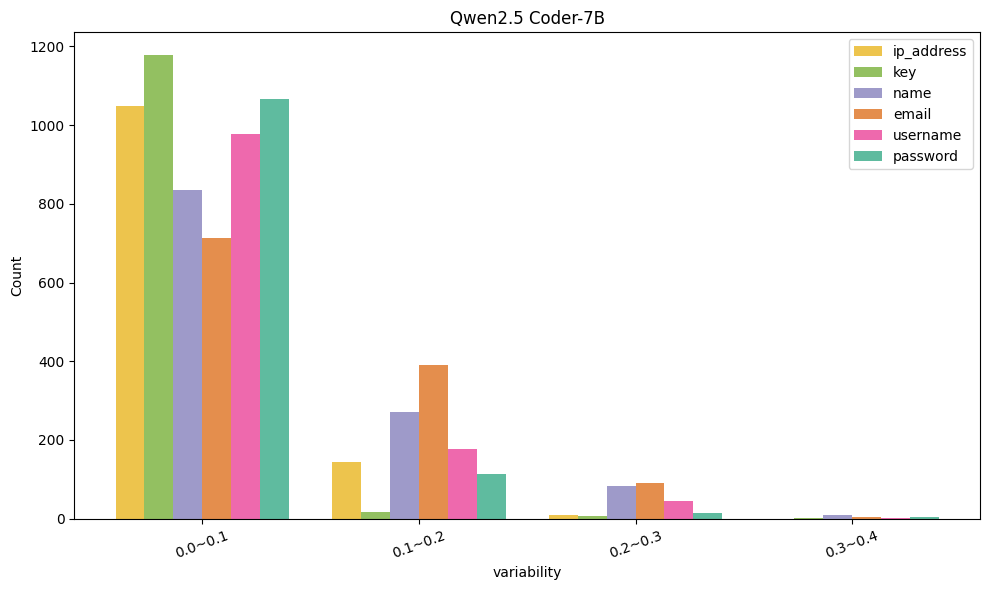


=== ip_address (confidence) ===
Bin 0.0~0.1: 0.0
Bin 0.1~0.2: 0.09
Bin 0.2~0.3: 0.4
Bin 0.3~0.4: 0.17
Bin 0.4~0.5: 0.02
Bin 0.5~0.6: 0.02
Bin 0.6~0.7: 0.02
Bin 0.7~0.8: 0.08
Bin 0.8~0.9: 0.17
Bin 0.9~1.0: 0.03
Sum of bins >= 0.5: 380 (0.32)

=== key (confidence) ===
Bin 0.0~0.1: 0.74
Bin 0.1~0.2: 0.08
Bin 0.2~0.3: 0.01
Bin 0.3~0.4: 0.01
Bin 0.4~0.5: 0.01
Bin 0.5~0.6: 0.01
Bin 0.6~0.7: 0.01
Bin 0.7~0.8: 0.01
Bin 0.8~0.9: 0.02
Bin 0.9~1.0: 0.1
Sum of bins >= 0.5: 176 (0.15)

=== name (confidence) ===
Bin 0.0~0.1: 0.27
Bin 0.1~0.2: 0.16
Bin 0.2~0.3: 0.14
Bin 0.3~0.4: 0.12
Bin 0.4~0.5: 0.12
Bin 0.5~0.6: 0.1
Bin 0.6~0.7: 0.06
Bin 0.7~0.8: 0.02
Bin 0.8~0.9: 0.0
Sum of bins >= 0.5: 229 (0.19)

=== email (confidence) ===
Bin 0.0~0.1: 0.01
Bin 0.1~0.2: 0.07
Bin 0.2~0.3: 0.15
Bin 0.3~0.4: 0.14
Bin 0.4~0.5: 0.16
Bin 0.5~0.6: 0.16
Bin 0.6~0.7: 0.16
Bin 0.7~0.8: 0.11
Bin 0.8~0.9: 0.04
Bin 0.9~1.0: 0.0
Sum of bins >= 0.5: 574 (0.48)

=== username (confidence) ===
Bin 0.0~0.1: 0.55
Bin 0.1~0.2: 0.15

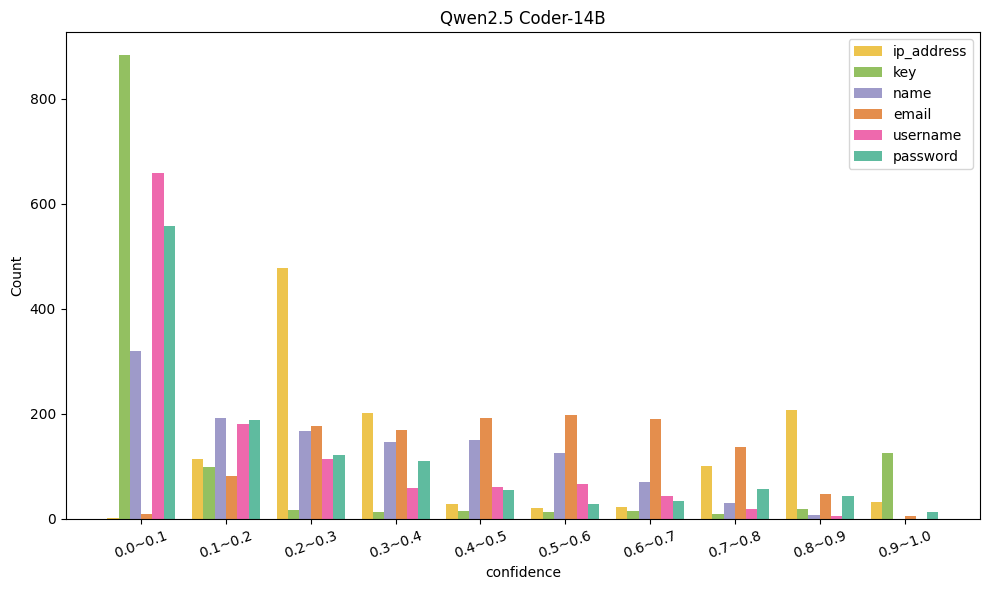


=== ip_address (variability) ===
Bin 0.0~0.1: 0.92
Bin 0.1~0.2: 0.07
Bin 0.2~0.3: 0.0
Sum of bins >= 0.5: 0 (0.0)

=== key (variability) ===
Bin 0.0~0.1: 0.98
Bin 0.1~0.2: 0.02
Bin 0.2~0.3: 0.0
Sum of bins >= 0.5: 0 (0.0)

=== name (variability) ===
Bin 0.0~0.1: 0.66
Bin 0.1~0.2: 0.28
Bin 0.2~0.3: 0.06
Bin 0.3~0.4: 0.0
Sum of bins >= 0.5: 0 (0.0)

=== email (variability) ===
Bin 0.0~0.1: 0.64
Bin 0.1~0.2: 0.32
Bin 0.2~0.3: 0.04
Bin 0.3~0.4: 0.0
Sum of bins >= 0.5: 0 (0.0)

=== username (variability) ===
Bin 0.0~0.1: 0.81
Bin 0.1~0.2: 0.16
Bin 0.2~0.3: 0.03
Sum of bins >= 0.5: 0 (0.0)

=== password (variability) ===
Bin 0.0~0.1: 0.9
Bin 0.1~0.2: 0.1
Bin 0.2~0.3: 0.01
Bin 0.3~0.4: 0.0
Sum of bins >= 0.5: 0 (0.0)


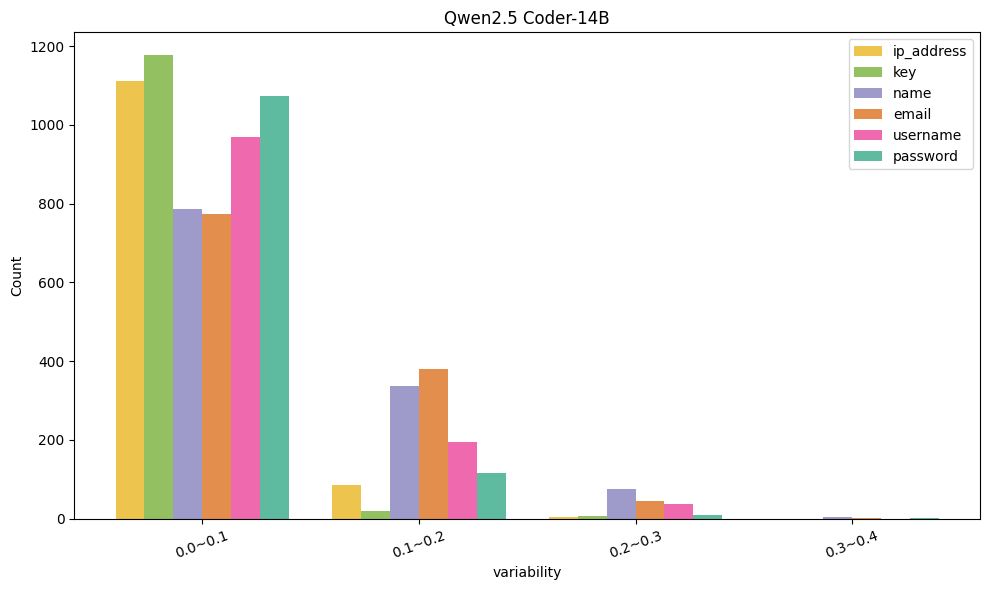

In [ ]:
bin_width = 0.1

def plot_bar_charts(draw_setting, dataset, x_name, model_name, ax_sub=None, legend=True):
    bins = np.arange(0, 1 + bin_width, bin_width)
    pii_types = list(dataset["confidences_by_type"].keys())
    n_types = len(pii_types)
    width = 0.8 / n_types  # total width for all bars at a bin is 0.8

    if ax_sub is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax_sub.get_figure()
        ax = ax_sub
    
    for i, pii_type in enumerate(pii_types):
        if x_name == "confidence":
            values = np.array(dataset["confidences_by_type"][pii_type])
        elif x_name == "variability":
            values = np.array(dataset["variabilities_by_type"][pii_type])
        else:
            raise ValueError(f"Invalid x_name: {x_name}")
        
        counts, _ = np.histogram(values, bins=bins)
        print(f"\n=== {pii_type} ({x_name}) ===")
        sum = 0
        for j in range(len(counts)):
            if counts[j] > 0:
                print(f"Bin {bins[j]:.1f}~{bins[j+1]:.1f}: {round(counts[j]/1200,2)}")
                if 0.1 <= bins[j] <= 0.5:
                    sum += counts[j]
        print(f"Sum of bins >= 0.5: {sum} ({round(sum/1200,2)})")
        # 只画有数据的bin
        nonzero_idx = np.nonzero(counts)[0]
        if len(nonzero_idx) == 0:
            continue
        x = nonzero_idx + i * width
        ax.bar(
            x,
            counts[nonzero_idx],
            width=width,
            color=draw_setting[pii_type]["color"],
            label=pii_type,
            alpha=0.7
        )
    # 
    all_nonzero_idx = set()
    for pii_type in pii_types:
        if x_name == "confidence":
            values = np.array(dataset["confidences_by_type"][pii_type])
        elif x_name == "variability":
            values = np.array(dataset["variabilities_by_type"][pii_type])
        else:
            continue
        counts, _ = np.histogram(values, bins=bins)
        all_nonzero_idx.update(np.nonzero(counts)[0])
    all_nonzero_idx = sorted(list(all_nonzero_idx))
    bin_labels = [f"{bins[j]:.1f}~{bins[j+1]:.1f}" for j in all_nonzero_idx]
    xticks = np.array(all_nonzero_idx) + width * (n_types-1) / 2
    ax.set_xticks(xticks)
    ax.set_xticklabels(bin_labels, rotation=20)

    ax.set_xlabel(f"{x_name}")
    ax.set_ylabel("Count")
    ax.set_title(f"{model_name}")
    if legend:
        ax.legend()
    if ax_sub is None:
        plt.tight_layout()
        plt.show()
    
for model_name, dataset in data_list:
    plot_bar_charts(draw_setting, dataset, "confidence", model_name)
    plot_bar_charts(draw_setting, dataset, "variability", model_name)
    
    
    
    
    


Stable Code-3B

=== ip_address (confidence) ===
Bin 0.1~0.2: 0.0
Bin 0.2~0.3: 0.02
Bin 0.3~0.4: 0.38
Bin 0.4~0.5: 0.28
Bin 0.5~0.6: 0.01
Bin 0.6~0.7: 0.01
Bin 0.7~0.8: 0.02
Bin 0.8~0.9: 0.09
Bin 0.9~1.0: 0.17
Sum of bins >= 0.5: 374 (0.31)

=== key (confidence) ===
Bin 0.0~0.1: 0.66
Bin 0.1~0.2: 0.17
Bin 0.2~0.3: 0.02
Bin 0.3~0.4: 0.01
Bin 0.4~0.5: 0.01
Bin 0.5~0.6: 0.0
Bin 0.6~0.7: 0.0
Bin 0.7~0.8: 0.01
Bin 0.8~0.9: 0.01
Bin 0.9~1.0: 0.11
Sum of bins >= 0.5: 160 (0.13)

=== name (confidence) ===
Bin 0.0~0.1: 0.37
Bin 0.1~0.2: 0.17
Bin 0.2~0.3: 0.14
Bin 0.3~0.4: 0.08
Bin 0.4~0.5: 0.04
Bin 0.5~0.6: 0.03
Bin 0.6~0.7: 0.08
Bin 0.7~0.8: 0.04
Bin 0.8~0.9: 0.03
Bin 0.9~1.0: 0.01
Sum of bins >= 0.5: 222 (0.18)

=== email (confidence) ===
Bin 0.0~0.1: 0.0
Bin 0.1~0.2: 0.01
Bin 0.2~0.3: 0.06
Bin 0.3~0.4: 0.15
Bin 0.4~0.5: 0.21
Bin 0.5~0.6: 0.18
Bin 0.6~0.7: 0.17
Bin 0.7~0.8: 0.13
Bin 0.8~0.9: 0.05
Bin 0.9~1.0: 0.04
Sum of bins >= 0.5: 688 (0.57)

=== username (confidence) ===
Bin 0.0~0.1: 0.49


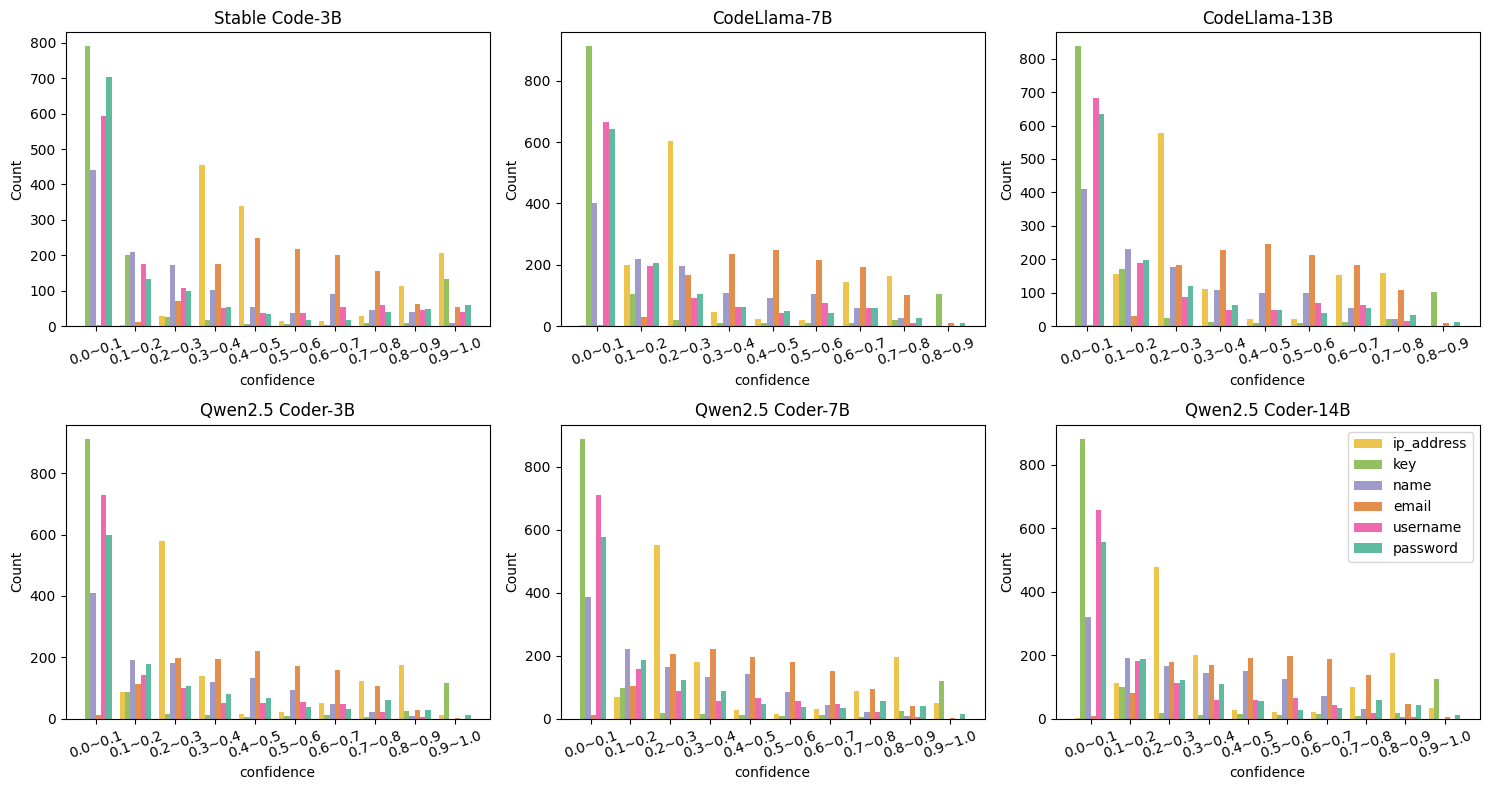

In [ ]:
# Plot all datasets in one figure
n_datasets = len(data_list)

cols = min(3, n_datasets)  # 
rows = (n_datasets + cols - 1) // cols  # 

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
if rows == 1 and cols == 1:
    axes = [[axes]]
elif rows == 1:
    axes = [axes]
elif cols == 1:
    axes = [[ax] for ax in axes]

for i, (model_name, dataset) in enumerate(data_list):
    row_idx = i // cols
    col_idx = i % cols
    
    show_legend = (i == n_datasets - 1)
    print(model_name)
    # plot_dataset_map(draw_setting, dataset, dataset_name=model_name, 
    #                 ds_frac=0.10, ax=axes[row_idx][col_idx], show_legend=show_legend)
    #sub_plot_dataset_map(draw_setting, dataset, model_name, ax_sub=axes[row_idx][col_idx], legend=show_legend)
    plot_bar_charts(draw_setting, dataset, "confidence", model_name, ax_sub=axes[row_idx][col_idx], legend=show_legend)


plt.tight_layout()
# save as pdf BEFORE showing
plt.savefig(f"pdf/confidence_bar_chart.pdf")
plt.show()


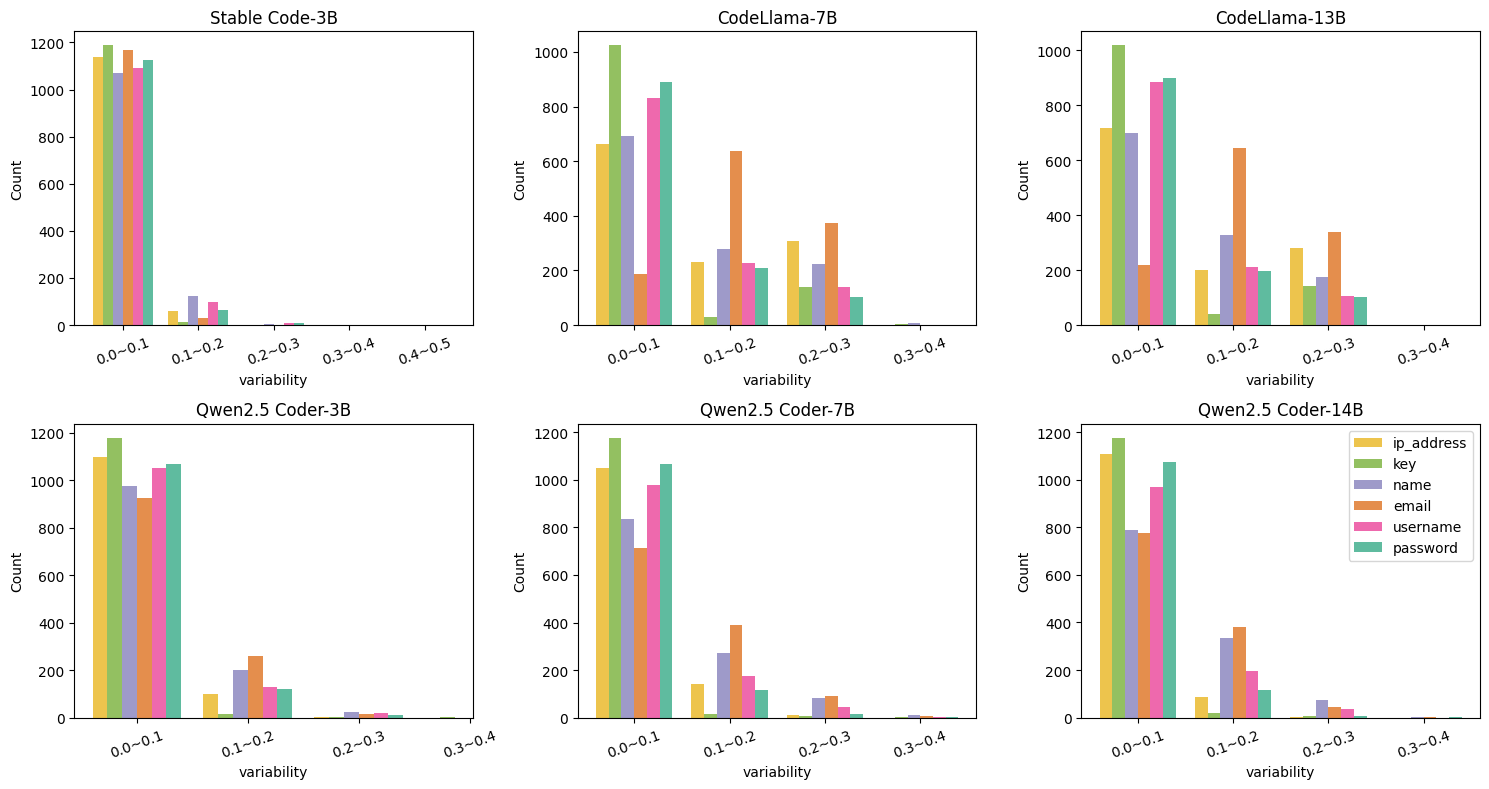

In [ ]:
# Plot all datasets in one figure
n_datasets = len(data_list)
# 计算行数和列数
cols = min(3, n_datasets)  # 最多3列
rows = (n_datasets + cols - 1) // cols  # 向上取整

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
if rows == 1 and cols == 1:
    axes = [[axes]]
elif rows == 1:
    axes = [axes]
elif cols == 1:
    axes = [[ax] for ax in axes]

for i, (model_name, dataset) in enumerate(data_list):
    row_idx = i // cols
    col_idx = i % cols
    
    show_legend = (i == n_datasets - 1)
    # plot_dataset_map(draw_setting, dataset, dataset_name=model_name, 
    #                 ds_frac=0.10, ax=axes[row_idx][col_idx], show_legend=show_legend)
    #sub_plot_dataset_map(draw_setting, dataset, model_name, ax_sub=axes[row_idx][col_idx], legend=show_legend)
    plot_bar_charts(draw_setting, dataset, "variability", model_name, ax_sub=axes[row_idx][col_idx], legend=show_legend)


plt.tight_layout()
# save as pdf BEFORE showing
plt.savefig(f"pdf/variability_bar_chart.pdf")
plt.show()

Stable Code-3B: [1.8561, 1.7939, 1.7436, 1.7028, 1.6698]
CodeLlama-7B: [1.7406, 1.6573, 1.6443, 1.6357, 1.6257]
CodeLlama-13B: [1.7599, 1.6418, 1.6278, 1.6173, 1.6053]
Qwen2.5 Coder-3B: [2.162, 2.1341, 2.1069, 2.088, 2.0757, 2.072, 2.047, 2.0413, 2.0372]
Qwen2.5 Coder-7B: [2.1227, 2.0866, 2.076, 2.0598]
Qwen2.5 Coder-14B: [2.087, 2.0449, 2.0287, 2.0078]


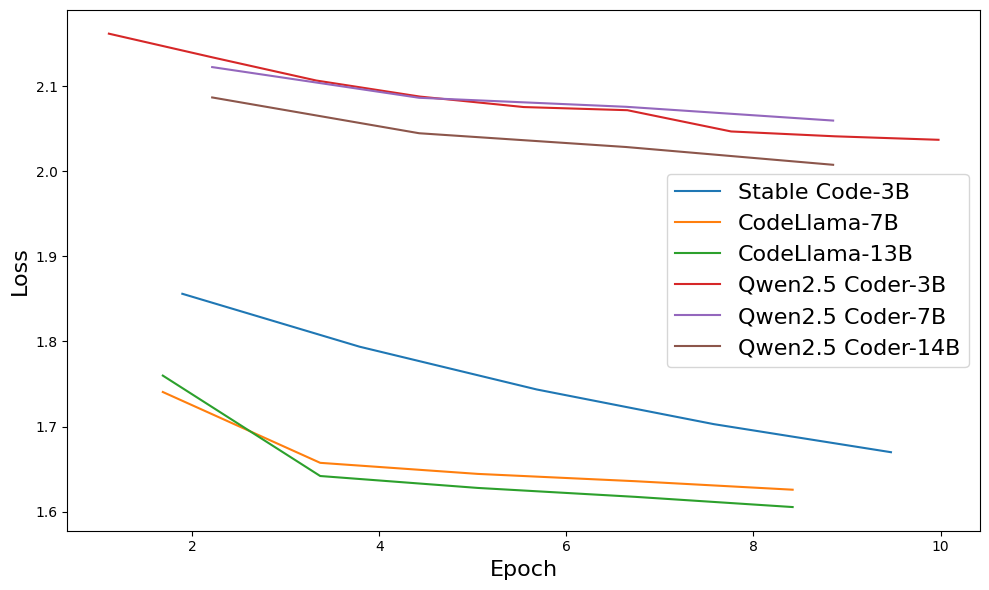

In [101]:
training_details_data = load_json_with_model_name(training_details)

plt.figure(figsize=(10, 6))
for model_name, training_detail in training_details_data:
    log_history = training_detail.get("log_history", [])
    losses = []
    for entry in log_history:
        if "loss" in entry:
            losses.append(entry["loss"])
    print(f"{model_name}: {losses}")


# draw the loss curve for each model
for model_name, training_detail in training_details_data:
    log_history = training_detail.get("log_history", [])
    epochs = []
    losses = []
    for entry in log_history:
        if "loss" in entry and "epoch" in entry:
            epochs.append(entry["epoch"])
            losses.append(entry["loss"])
    if epochs and losses:
        plt.plot(epochs, losses, label=model_name)

plt.xlabel("Epoch", fontsize=16)
plt.ylabel("Loss", fontsize=16)
#plt.title("Training Loss Curve")
plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig("pdf/training_loss_curve.pdf")
plt.show()
